In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.lines as mlines
import seaborn as sns
import scipy.stats as stats
import os

# === 绘图配置 ===
sns.set_style("whitegrid")
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial'] 
plt.rcParams['axes.unicode_minus'] = False

# 确保保存图片的文件夹存在
os.makedirs('./visualization/', exist_ok=True)

# 设置随机种子函数
def set_seed(seed=42):
    np.random.seed(seed)
    print(f"随机种子已设置为: {seed}")

set_seed(42)

随机种子已设置为: 42


In [12]:
# === 配置路径 ===
DATA_FOLDER = '../data/20260106_pose_infer'   
RESULT_CSV = "./results/ImprovedTransformerModel/20260116_002929.csv" 

# === 加载数据 ===
if os.path.exists(RESULT_CSV):
    df = pd.read_csv(RESULT_CSV)
    print(f"成功加载 CSV，原始样本数: {len(df)}")
    
    # 过滤：只保留落地时间 <= 245 帧的样本
    # df = df.loc[df['label_time'] <= 245].copy()
    # print(f"过滤后样本数 (Label Time <= 245): {len(df)}")
    
    df['err_x'] = df['pred_x'] - df['label_x']
    df['err_y'] = df['pred_y'] - df['label_y']
    df['err_z'] = df['pred_z'] - df['label_z']
    df['err_time'] = abs(df['pred_time'] - df['label_time'])
    df['err_euclidean'] = np.sqrt(df['err_x']**2 + df['err_y']**2 + df['err_z']**2)
    df['std_euclidean'] = np.sqrt(df['std_x']**2 + df['std_y']**2 + df['std_z']**2)
    
    pred_dir = df[["pred_dir_x", "pred_dir_y"]].values
    label_dir = df[["label_dir_x", "label_dir_y"]].values
    cos_sim = np.sum(pred_dir * label_dir, axis=1) / (
            np.linalg.norm(pred_dir, axis=1) * np.linalg.norm(label_dir, axis=1) + 1e-6)
    df['err_dir'] = np.degrees(np.arccos(np.clip(cos_sim, -1.0, 1.0)))
    
else:
    print(f"错误：找不到文件 {RESULT_CSV}")

成功加载 CSV，原始样本数: 51


In [3]:
# 基础误差可视化函数定义

def visualize_group(group, group_name, log_time, avg_err, save_path):
    line_colors = [(0.7, 0.7, 0.7), (0.4, 0.4, 0.8), (0.8, 0.4, 0.4)]
    pred_xy = group[["pred_x", "pred_y"]].values
    target_xy = group[["label_x", "label_y"]].values
    
    threshold = 1 # 采样率
    N = pred_xy.shape[0]
    if N > 0:  
        mask = np.random.rand(N) < threshold
        pred_xy = pred_xy[mask]
        target_xy = target_xy[mask]
        
        plt.figure(figsize=(10, 8))
        for (px, py), (tx, ty) in zip(pred_xy, target_xy):
            random_color = np.random.choice(len(line_colors)) 
            plt.scatter(tx, ty, c="blue", marker="o", s=15, 
                    label="True" if "True" not in plt.gca().get_legend_handles_labels()[1] else "")
            plt.scatter(px, py, c="red", marker="x", s=20, 
                    label="Predict" if "Predict" not in plt.gca().get_legend_handles_labels()[1] else "")
            plt.plot([tx, px], [ty, py], c=line_colors[random_color], linestyle="--", linewidth=0.5, alpha=0.6)
        
        plt.xlim(0, 600); plt.ylim(-300, 300)
        plt.xlabel("X"); plt.ylabel("Y")
        plt.title(f"{group_name} (Avg L2 Dist: {avg_err:.2f})")
        plt.legend()
        plt.savefig(os.path.join(save_path, f"{group_name}_{log_time}.pdf"))
        # plt.show()

def visual_df(name, log_time, df):
    save_path = f'./visualization/'
    os.makedirs(save_path, exist_ok=True)
    
    # 打印统计
    print(f"=== {name} 误差统计 ===")
    print(f"落点误差(Euclidean): {df['err_euclidean'].mean():.2f} cm")
    print(f"时间误差(Time): {df['err_time'].mean():.2f} frames")
    print(f"角度误差(Direction): {df['err_dir'].mean():.2f} degrees")

    # 分组绘图
    avg_err = df['err_euclidean'].mean()
    group_high = df[df['err_euclidean'] > avg_err]
    group_low = df[df['err_euclidean'] <= avg_err]
    save_path_groups = "./visualization/xyz_error_groups/"
    os.makedirs(save_path_groups, exist_ok=True)
    
    visualize_group(group_high, "Above_Avg_Err", log_time, avg_err, save_path_groups)
    visualize_group(group_low, "Below_Avg_Err", log_time, avg_err, save_path_groups)

    # 绘制分布直方图
    plt.figure(figsize=(12, 10))
    
    # (1) 落点误差散点
    plt.subplot(2, 2, 1)
    plt.scatter(df['err_x'], df['err_y'], alpha=0.5, s=10)
    plt.axhline(0, c="gray", ls="--"); plt.axvline(0, c="gray", ls="--")
    plt.xlim(-400, 400); plt.ylim(-400, 400); plt.title("Landing Error Scatter")
    
    # (2) 欧氏距离直方图
    plt.subplot(2, 2, 2)
    plt.hist(df['err_euclidean'], bins=50, color="steelblue", alpha=0.7)
    plt.axvline(avg_err, c="red", ls="--", label=f"Mean: {avg_err:.1f}")
    plt.xlim(0, 500); plt.title("Euclidean Error Dist"); plt.legend()
    
    # (3) 时间误差
    plt.subplot(2, 2, 3)
    plt.hist(df['err_time'], bins=50, color="orange", alpha=0.7)
    plt.xlim(0, 200); plt.title("Time Error Dist") 
    
    # (4) 方向误差
    plt.subplot(2, 2, 4)
    plt.hist(df['err_dir'], bins=50, color="green", alpha=0.7)
    plt.xlim(0, 180); plt.title("Direction Error Dist")
    
    plt.tight_layout()
    file_name = name + "_" + log_time + "_error_distributions.pdf"
    file_path = os.path.join(save_path, file_name)
    plt.savefig(file_path)
    # plt.show()

=== ImprovedTransformerModel 误差统计 ===
落点误差(Euclidean): 245.89 cm
时间误差(Time): 168.95 frames
角度误差(Direction): 78.68 degrees


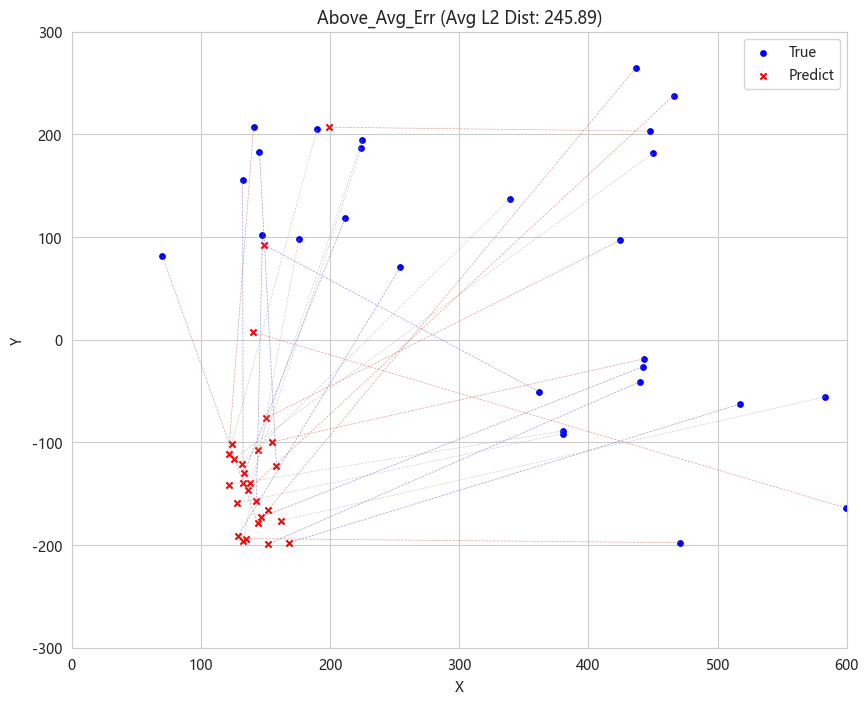

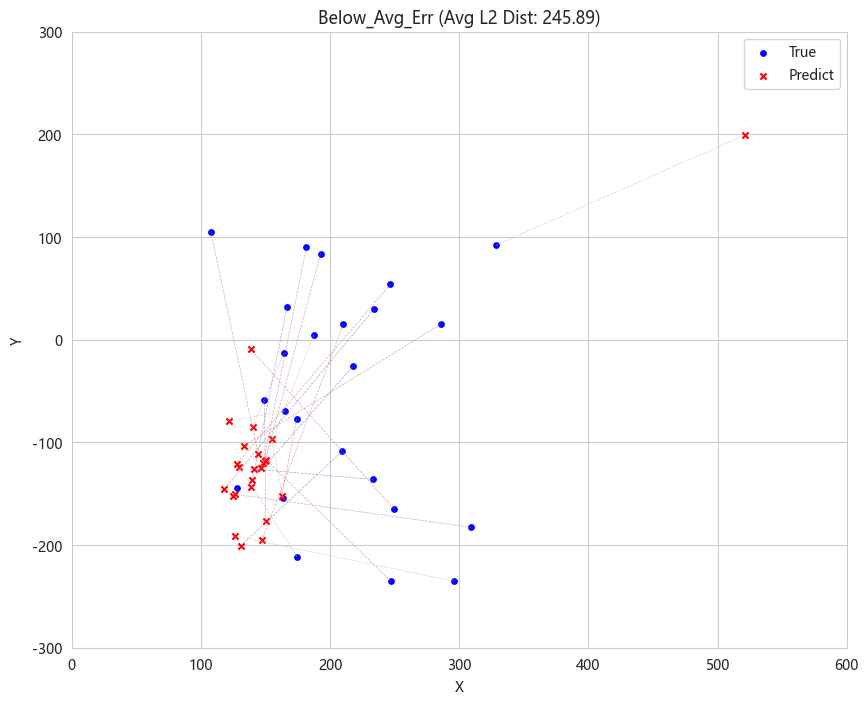

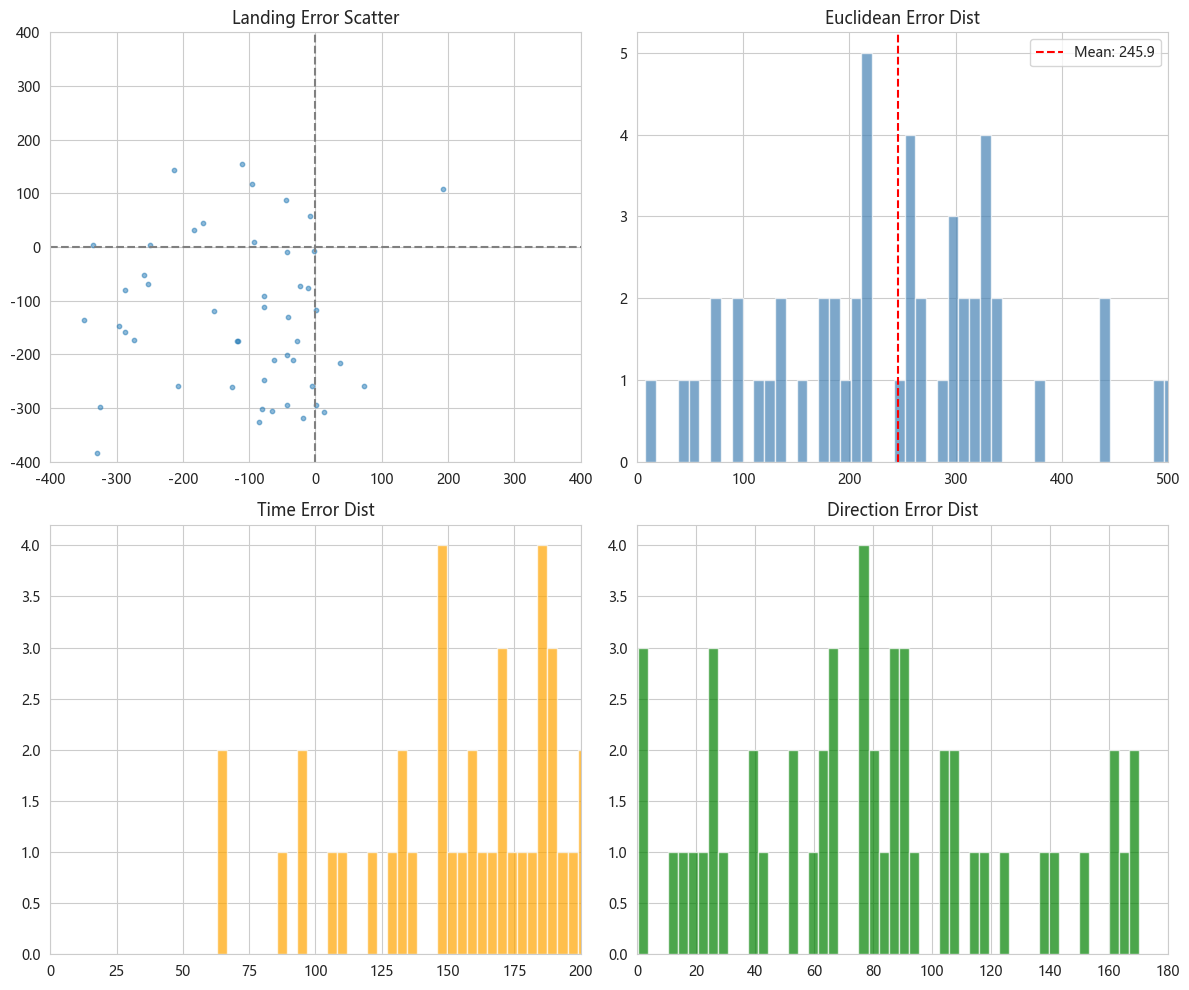

In [4]:
if 'df' in locals():
    visual_df('ImprovedTransformerModel', 'Basic_Analysis', df)
else:
    print("请先运行 Cell 2 加载数据")

In [7]:
# 不确定性可视化函数定义

def visual_uncertainty(df, threshold=75):
    # 1. 统计分析
    print(f"--- 阈值 Threshold = {threshold} ---")
    df_less_1m = df[df['err_euclidean'] <= 100]
    df_more_1m = df[df['err_euclidean'] > 100]

    less_1m = len(df_less_1m[df_less_1m['std_euclidean'] < threshold])
    more_1m = len(df_more_1m[df_more_1m['std_euclidean'] > threshold])
    print(f"在设定不确定性的截断阈值为{threshold}的情况下：")
    print(f"保留的<1m样本占比 {less_1m / len(df_less_1m)}")
    print(f"丢弃的>1m样本占比 {more_1m / len(df_more_1m)}")

    df_less_threshold = df[df['std_euclidean'] <= threshold]
    df_more_threshold = df[df['std_euclidean'] > threshold]
    less_threshold_true = len(df_less_threshold[df_less_threshold['err_euclidean'] <= 100])
    more_threshold_true = len(df_more_threshold[df_more_threshold['err_euclidean'] > 100])
    print(f"保留的样本中正确保留占比 {less_threshold_true / len(df_less_threshold)}")
    print(f"丢弃的样本中正确丢弃占比 {more_threshold_true / len(df_more_threshold)}")

    print("\n======== 不确定性估计可视化 ========")
    # 2. 散点图
    plt.figure(figsize=(10, 6))

    valid_data = df[['err_euclidean', 'std_euclidean']].dropna()
    x = valid_data['err_euclidean']
    y = valid_data['std_euclidean']
    
    r, p_value = stats.pearsonr(x, y)
    
    # sns.regplot 会自动画出散点和线性回归拟合线
    sns.regplot(
        x=x, 
        y=y, 
        data=valid_data,
        scatter_kws={'alpha': 0.6, 's': 20, 'color': 'steelblue'}, # 散点样式
        line_kws={'color': 'red', 'linestyle': '--', 'linewidth': 1.5}, # 回归线样式
        ci=95 # 显示 95% 置信区间 (阴影部分)
    )
    
    # 使用 LaTeX 格式使得 r 显示为斜体
    plt.title(f'Predictive Error vs. Uncertainty (Pearson $r={r:.3f}$)', fontsize=14)
    
    plt.xlabel('Error (cm)', fontsize=12)
    plt.ylabel('Uncertainty (std)', fontsize=12)
    plt.ylim(0, 250)
    plt.grid(True, ls='--', alpha=0.6)
    
    # 保存和显示
    plt.savefig('visualization/Error-std Correlation.png', bbox_inches='tight')
    plt.show()

--- 阈值 Threshold = 70 ---
在设定不确定性的截断阈值为70的情况下：
保留的<1m样本占比 0.0
丢弃的>1m样本占比 0.7727272727272727
保留的样本中正确保留占比 0.0
丢弃的样本中正确丢弃占比 0.8292682926829268

======== 不确定性估计可视化 ========


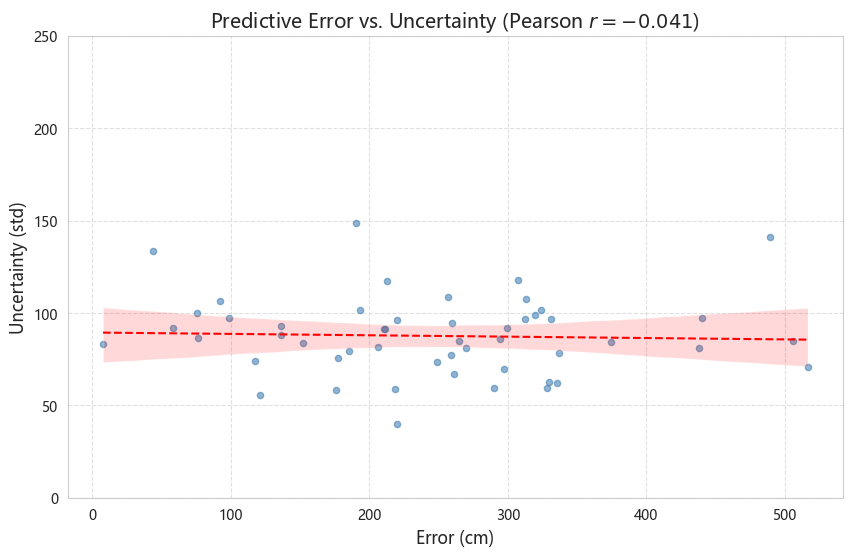

In [8]:
if 'df' in locals():
    # 修改不确定性截断阈值
    visual_uncertainty(df, threshold=70)

In [9]:
# 特征-误差分析通用函数

import scipy.stats as stats
from scipy.signal import savgol_filter

# === 通用文件读取函数 ===
def parse_pose_sequence(lines):
    """解析文本数据"""
    frames = []
    for line in lines:
        coords = np.array([float(num) for num in line.strip().split(':')[1].split(',')])
        coords = coords[:63]
        frames.append(coords.reshape(21, 3))
    return np.array(frames)

# === 通用数据处理函数 ===
def extract_feature_and_error(df, data_folder, feature_extractor_func):
    """
    通用处理器：遍历数据，应用用户自定义的 feature_extractor_func
    """
    features = []
    errors = []
    
    # 预加载进度条 (可选)
    # from tqdm import tqdm
    # iterator = tqdm(df.iterrows(), total=len(df))
    
    for index, row in df.iterrows():
        try:
            # 读取数据
            file_path = os.path.join(data_folder, row['file_name'])
            with open(file_path, 'r') as f:
                lines = f.readlines()
            if len(lines) > 0: del lines[-1]
            seq = parse_pose_sequence(lines) # 使用你之前的解析函数
            
            # === 核心：调用用户传入的函数 ===
            val = feature_extractor_func(seq)
            
            if val is not None: # 允许函数返回 None 跳过某些样本
                features.append(val)
                errors.append(row['err_euclidean']) # 假设我们分析欧氏距离误差
                
        except Exception as e:
            continue
            
    return np.array(features), np.array(errors)

# === 通用可视化绘图函数 ===
def plot_feature_analysis(feature_vals, error_vals, feature_name, 
                                  plot_type='scatter', bins=10, 
                                  remove_outliers=True, quantile=0.98):
    """
    增强版绘图函数：支持自动剔除异常值
    quantile=0.98 表示只保留 98% 的数据，剔除最大的 2%
    """
    # 复制数据以免修改原始变量
    f_data = feature_vals.copy()
    e_data = error_vals.copy()
    
    # === 核心：异常值剔除 ===
    if remove_outliers:
        # 计算分位阈值 (例如 98% 分位数)
        # 意味着我们认为速度最快的那 2% 可能是噪声
        threshold = np.percentile(f_data, quantile * 100)
        
        # 生成掩码 (Mask)
        mask = f_data <= threshold
        
        # 打印剔除信息
        n_removed = len(f_data) - np.sum(mask)
        # print(f"已剔除 {n_removed} 个异常样本 (阈值 > {threshold:.2f})")
        
        # 应用掩码
        f_data = f_data[mask]
        e_data = e_data[mask]

    plt.figure(figsize=(10, 6))
    
    if plot_type == 'scatter':
        # 散点图
        sns.scatterplot(x=f_data, y=e_data, alpha=0.5, s=30, color='steelblue')
        
        # 鲁棒回归线 (Robust Regression)
        # ci=None 加快绘制速度
        sns.regplot(x=f_data, y=e_data, scatter=False, color='red', 
                    line_kws={'linestyle':'--'}, ci=95)
        
        # 计算相关系数
        corr, p_value = stats.pearsonr(f_data, e_data)
        plt.title(f"Feature: {feature_name} (r={corr:.3f})", fontsize=14)
        plt.xlabel(f"{feature_name} Value")
        plt.ylabel("Prediction Error (cm)")
        
    elif plot_type == 'box':
        # 箱线图
        df_temp = pd.DataFrame({'feature': f_data, 'error': e_data})
        df_temp['bin'] = pd.cut(df_temp['feature'], bins=bins)
        
        sns.boxplot(data=df_temp, x='bin', y='error', hue='bin', palette="Blues", legend=False)
        plt.xticks(rotation=45)
        plt.title(f"Feature: {feature_name} (Boxplot", fontsize=14)
        plt.xlabel(f"{feature_name} Range")
        plt.ylabel("Prediction Error (cm)")

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


def analyze_feature_interaction(df, data_folder, func_x, func_y, x_name, y_name, bins=8):
    """
    双特征交互分析引擎
    
    参数:
        func_x: 第一个特征计算函数 (作为 X 轴)
        func_y: 第二个特征计算函数 (作为 Y 轴)
        x_name: X 轴特征的名称
        y_name: Y 轴特征的名称
        bins: 热力图的分箱数量 (默认 8x8)
    """
    vals_x = []
    vals_y = []
    errors = []
    
    # === 1. 双重特征提取 ===
    for index, row in df.iterrows():
        try:
            file_path = os.path.join(data_folder, row['file_name'])
            # 简单读取，这里假设你有 parse_pose_sequence 函数
            with open(file_path, 'r') as f:
                lines = f.readlines()
            if len(lines) > 0: del lines[-1]
            seq = parse_pose_sequence(lines)
            
            # 分别调用两个函数
            vx = func_x(seq)
            vy = func_y(seq)
            
            if vx is not None and vy is not None:
                vals_x.append(vx)
                vals_y.append(vy)
                errors.append(row['err_euclidean'])
        except Exception as e:
            continue
            
    # 转为 DataFrame 方便处理
    data = pd.DataFrame({
        x_name: vals_x,
        y_name: vals_y,
        'Error': errors
    })
    
    # === 2. 数据清洗 (可选：剔除极值) ===
    # 剔除 X 和 Y 轴最大的 1% 极值，防止热力图被压缩
    q_x = data[x_name].quantile(0.99)
    q_y = data[y_name].quantile(0.99)
    data = data[(data[x_name] <= q_x) & (data[y_name] <= q_y)]
    
    # === 3. 绘图区域 ===
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # --- 图 A: 散点气泡图 (Bubble Plot) ---
    # X=特征1, Y=特征2, 颜色深浅=误差大小
    sc = axes[0].scatter(data[x_name], data[y_name], 
                         c=data['Error'], cmap='Reds', 
                         alpha=0.7, edgecolors='grey', linewidth=0.3)
    axes[0].set_xlabel(x_name)
    axes[0].set_ylabel(y_name)
    axes[0].set_title(f"Scatter Interaction: Color = Error", fontsize=14)
    plt.colorbar(sc, ax=axes[0], label='Prediction Error (cm)')
    axes[0].grid(True, linestyle='--', alpha=0.5)

    # --- 图 B: 2D 热力图 (Binning Heatmap) ---
    # 将 X 和 Y 分别切成 N 份，计算每个格子里的平均误差
    data['x_bin'] = pd.cut(data[x_name], bins=bins)
    data['y_bin'] = pd.cut(data[y_name], bins=bins)
    
    # 聚合计算均值
    heatmap_data = data.pivot_table(index='y_bin', columns='x_bin', values='Error', aggfunc='mean', observed=False)
    
    # 绘制热力图
    # 注意：Y轴通常需要翻转，让小数值在下方
    sns.heatmap(heatmap_data.iloc[::-1], ax=axes[1], annot=True, fmt=".1f", 
                cmap="YlOrRd", cbar_kws={'label': 'Mean Error'})
    
    axes[1].set_title(f"Heatmap: Mean Error in {bins}x{bins} Regions", fontsize=14)
    axes[1].set_xlabel(f"{x_name} Bins")
    axes[1].set_ylabel(f"{y_name} Bins")
    
    plt.tight_layout()
    plt.show()

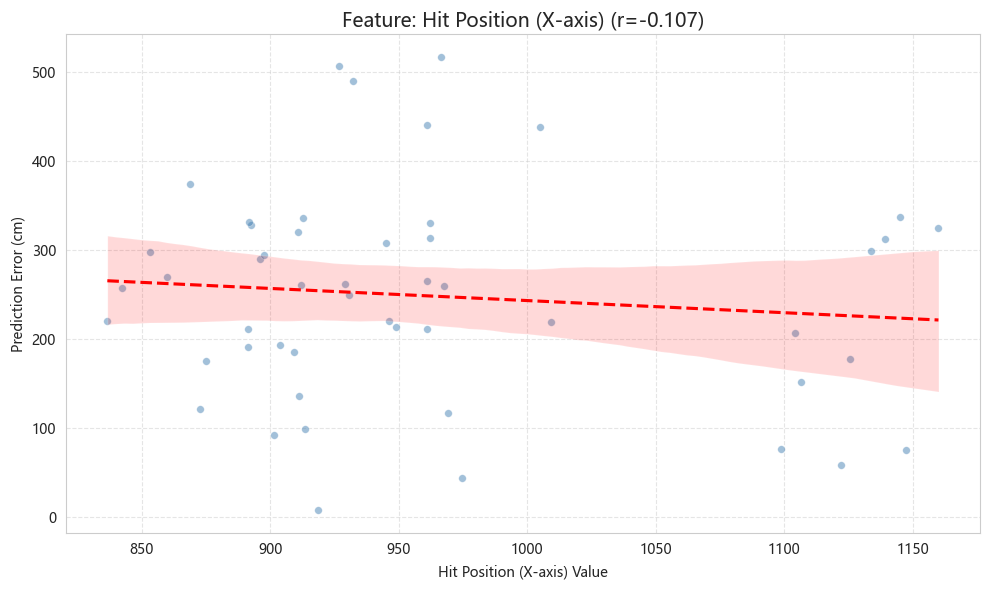

In [13]:
# 击球位置-误差分析

def get_hit_height(seq):
    """自定义逻辑：获取击球瞬间球拍的位置 (X轴)"""
    WRIST = 20
    X_AXIS = 0
    return seq[-6, WRIST, X_AXIS]

# === 执行分析 ===
if 'df' in locals():
    feats, errs = extract_feature_and_error(df, DATA_FOLDER, get_hit_height)
    
    plot_feature_analysis(feats, errs, feature_name="Hit Position (X-axis)", plot_type='scatter')

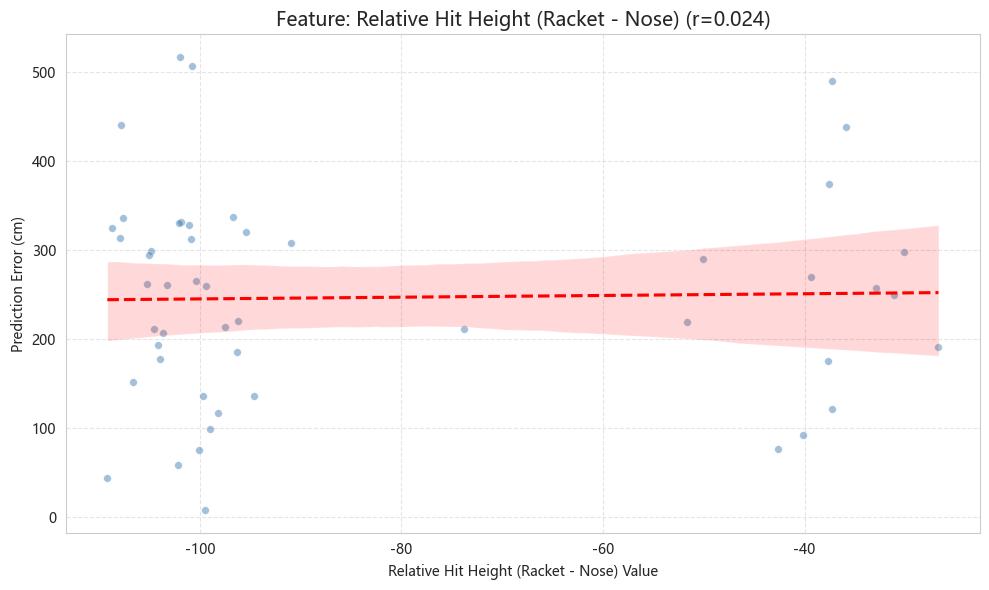

In [14]:
# 击球高度-误差分析

def get_relative_height(seq):
    """
    计算击球瞬间：手腕相对于鼻子(或头部)的垂直高度差。
    正值表示过顶击球，负值表示下手球。
    """
    RACKET_IDX = 20
    NOSE_IDX = 0  # 假设 0 是鼻子/头部中心
    IMPACT_IDX = -6  # 击球帧
    
    # 获取 Z 轴 (高度)
    racket_z = seq[IMPACT_IDX, RACKET_IDX, 2]
    nose_z = seq[IMPACT_IDX, NOSE_IDX, 2]
    
    return racket_z - nose_z

# === 执行分析 ===
if 'df' in locals():
    feats, errs = extract_feature_and_error(df, DATA_FOLDER, get_relative_height)
    
    plot_feature_analysis(feats, errs, feature_name="Relative Hit Height (Racket - Nose)", plot_type='scatter')

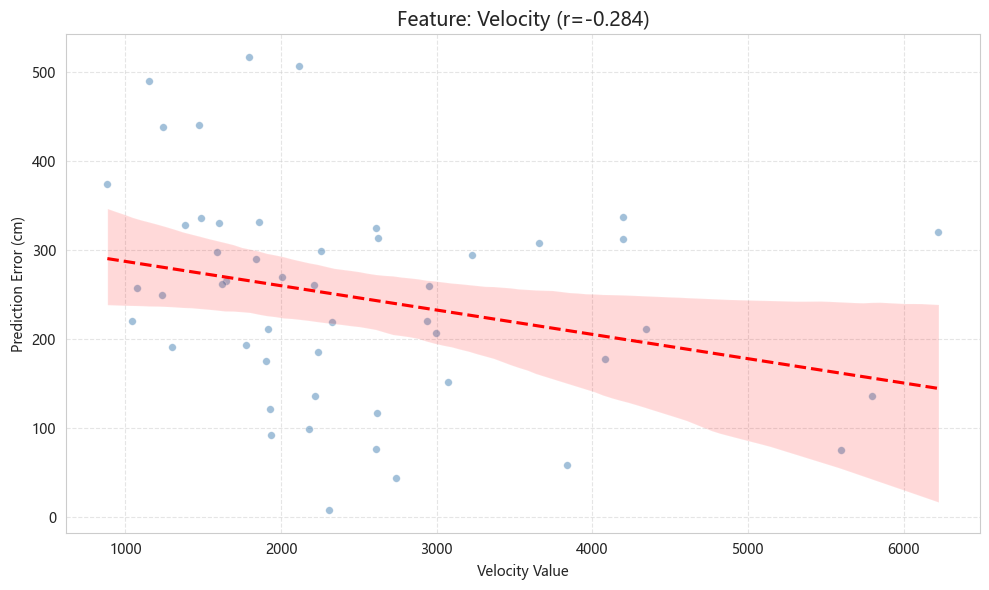

In [15]:
# 挥拍速度-误差分析

def get_max_velocity(seq):
    """
    提取击球发力阶段的最大瞬时速度（标量）。
    
    参数:
        seq: np.array, shape (105, 21, 3) 或者 (T, Joints, 3)
    返回:
        float: 发力窗口内的最大速度值 (单位/秒)。
    """
    # === 1. 参数配置 (适配 245 FPS) ===
    WRIST_IDX = 20        # 手腕/球拍关键点索引
    FPS = 245.0           # 采样率
    DT = 1.0 / FPS        # 时间微分间隔
    
    # === 2. 窗口定义 (适配 105 帧结构) ===
    # 序列逻辑：前100帧(准备+挥拍) -> 第100帧左右(击球) -> 后5帧(随挥)
    # 击球点 (Impact) 约在倒数第 6 帧
    IMPACT_IDX = -6       
    
    # 观测窗口 (Focus Window)：
    # 我们只关心击球前约 120ms (30帧) 到击球瞬间这一段的"爆发速度"。
    # 窗口范围：[倒数第36帧] 到 [倒数第4帧]
    WINDOW_START = -36    
    WINDOW_END = IMPACT_IDX + 2 

    # === 3. 数据提取 ===
    # 提取手腕的三维轨迹 -> Shape: (105, 3)
    wrist_pos = seq[:, WRIST_IDX, :]

    # === 4. 计算瞬时速度 (Savitzky-Golay 平滑微分) ===
    # 原理：在极短的时间窗口内拟合抛物线并求导，比简单的 (x2-x1) 更抗噪且精准。
    # window_length=9 (约36ms): 窗口够短，不会抹平峰值；窗口够长，能滤除抖动。
    # deriv=1: 求一阶导数 (速度)
    vel_vec = savgol_filter(wrist_pos, window_length=9, polyorder=2, 
                            deriv=1, delta=DT, axis=0)
    
    # 计算合速度 (标量 magnitude) -> Shape: (105,)
    vel_mag = np.linalg.norm(vel_vec, axis=1)

    # === 5. 提取峰值 ===
    # 在发力窗口内寻找最大值
    swing_window_vals = vel_mag[WINDOW_START : WINDOW_END]
    max_velocity = np.max(swing_window_vals)

    return max_velocity

# === 执行分析 ===
if 'df' in locals():
    # 1. 提取数据
    feats, errs = extract_feature_and_error(df, DATA_FOLDER, get_max_velocity)
    
    # 2. 绘制散点图 (看整体趋势)
    plot_feature_analysis(feats, errs, feature_name="Velocity", plot_type='scatter')
    
    # 3. 绘制箱线图 (看在哪个速度区间误差最大)
    # plot_feature_analysis(feats, errs, feature_name="Swing Velocity (Last 5 Frames)", plot_type='box', bins=8)

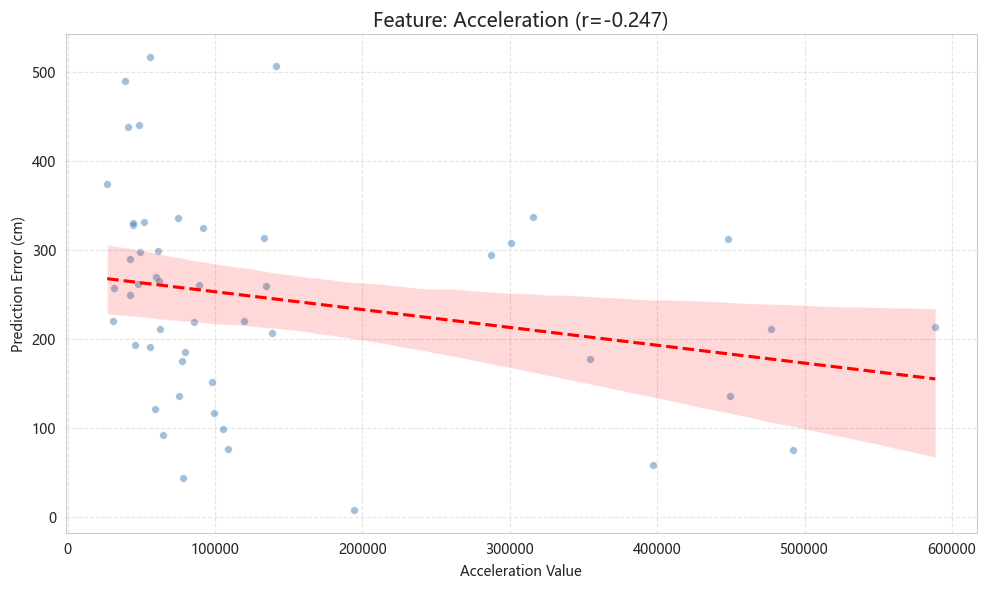

In [16]:
# 加速度-误差分析

def get_max_acceleration(seq):
    """
    提取击球过程中的最大瞬时加速度（爆发力峰值）。
    使用 Savitzky-Golay 滤波器直接计算二阶导数。
    
    参数:
        seq: np.array, shape (105, 21, 3)
    返回:
        float: 最大加速度值 (单位: dist/s^2)
    """
    # === 1. 参数配置 ===
    WRIST_IDX = 20
    FPS = 245.0
    DT = 1.0 / FPS
    
    # === 2. 关键索引定义 ===
    # 击球点 (Impact) 约在倒数第 6 帧 (第100帧左右)
    IMPACT_IDX = -6
    
    # 观测窗口 (Focus Window):
    # 加速度峰值通常出现在击球前的手腕制动瞬间 (Whiplash effect)
    # 我们取击球前约 150ms 到击球瞬间
    WINDOW_START = -36    
    WINDOW_END = IMPACT_IDX + 1

    # === 3. 数据提取 ===
    # shape: (105, 3)
    wrist_pos = seq[:, WRIST_IDX, :]

    # === 4. 计算加速度 (核心区别) ===
    # 使用 Savitzky-Golay 滤波器计算二阶导数 (deriv=2)
    # window_length=11 (约45ms): 加速度比速度对噪声更敏感，需要稍长的窗口来平滑
    # polyorder=2: 使用二次多项式拟合，适合捕捉抛物线式的加速过程
    acc_vec = savgol_filter(wrist_pos, window_length=11, polyorder=2, 
                            deriv=2, delta=DT, axis=0)
    
    # 计算加速度模长 (合加速度)
    # shape: (105,)
    acc_mag = np.linalg.norm(acc_vec, axis=1)

    # === 5. 提取峰值 ===
    # 只在发力窗口内找最大值，避开引拍初期和击球后震动的干扰
    swing_window_vals = acc_mag[WINDOW_START : WINDOW_END]
    max_acceleration = np.max(swing_window_vals)

    return max_acceleration

# === 执行分析 ===
if 'df' in locals():
    feats, errs = extract_feature_and_error(df, DATA_FOLDER, get_max_acceleration)
    
    plot_feature_analysis(feats, errs, feature_name="Acceleration", plot_type='scatter')

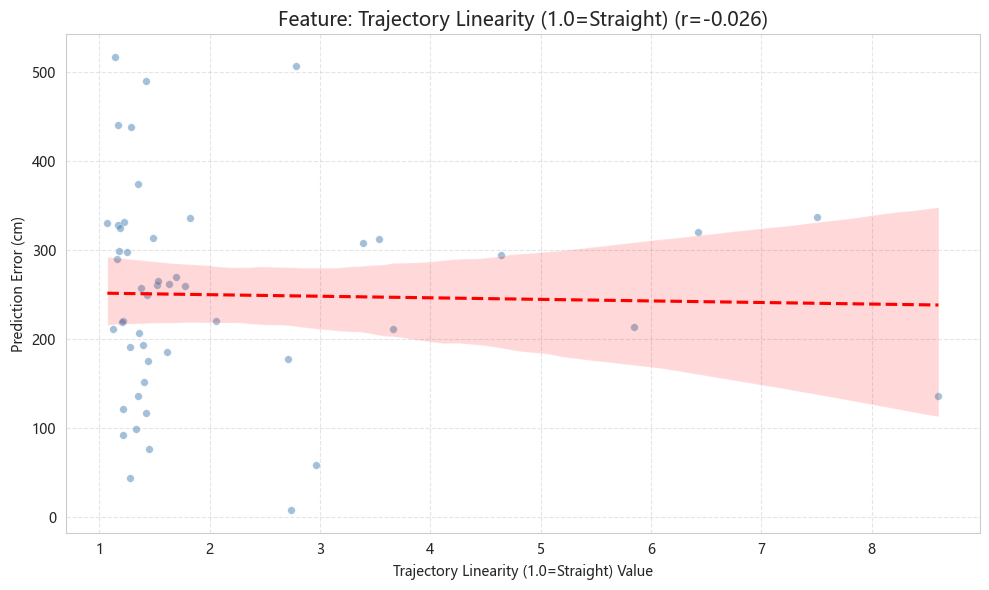

In [17]:
# 击球轨迹“直线性”-误差分析

def get_racket_linearity(seq):
    """
    计算击球前轨迹的"直线性"。
    返回值为 1.0 表示完美的直线；数值越大表示轨迹越弯曲（可能是假动作）。
    """
    WRIST_IDX = 20
    IMPACT_IDX = -6
    WINDOW_LEN = 20 # 观察击球前约 80ms 的轨迹
    
    # 获取这段时间的球拍坐标序列
    # shape: (20, 3)
    start_idx = IMPACT_IDX - WINDOW_LEN
    segment = seq[start_idx : IMPACT_IDX, WRIST_IDX, :]
    
    # 1. 计算实际路径总长度 (Path Length)
    # np.diff 计算相邻帧的位移向量，norm 计算长度，sum 累加
    steps = np.linalg.norm(np.diff(segment, axis=0), axis=1)
    path_length = np.sum(steps)
    
    # 2. 计算首尾直线距离 (Euclidean Distance)
    start_point = segment[0]
    end_point = segment[-1]
    displacement = np.linalg.norm(end_point - start_point)
    
    # 3. 计算比值 (防止除零)
    if displacement < 1e-6:
        return 1.0
    
    linearity_ratio = path_length / displacement
    return linearity_ratio

# === 执行分析 ===
if 'df' in locals():
    feats, errs = extract_feature_and_error(df, DATA_FOLDER, get_racket_linearity)
    
    plot_feature_analysis(feats, errs, "Trajectory Linearity (1.0=Straight)", plot_type='scatter')

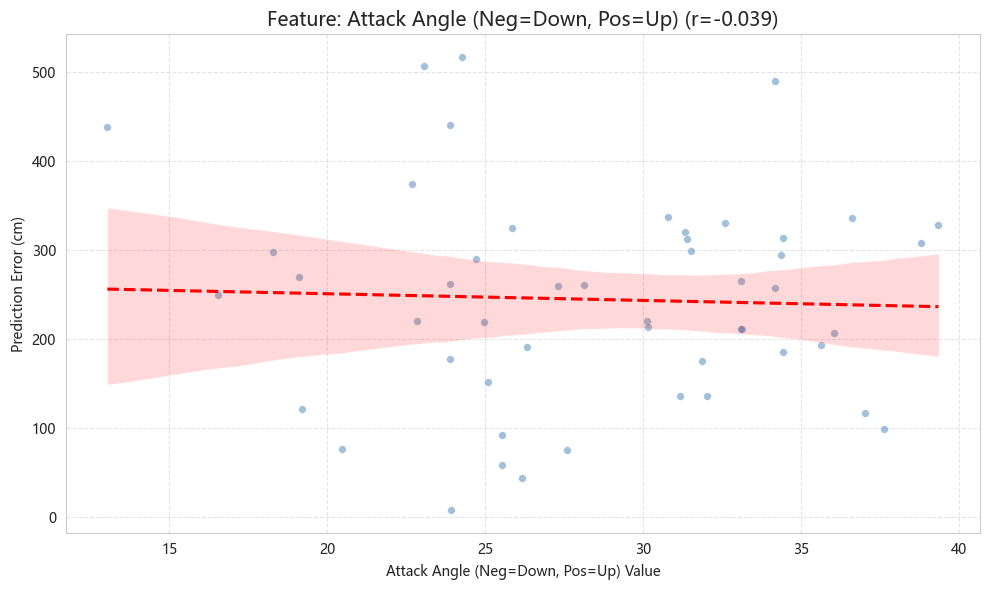

In [18]:
def get_attack_angle(seq):
    """
    计算击球瞬间，球拍运动方向与水平面的夹角 (度数)。
    +90度: 垂直向上; -90度: 垂直向下; 0度: 水平
    """
    WRIST_IDX = 20
    IMPACT_IDX = -6
    FPS = 245.0
    DT = 1.0 / FPS
    
    # 取击球点附近的一小段来算瞬时速度向量
    # 使用 savgol 比较平滑
    wrist_pos = seq[:, WRIST_IDX, :]
    vel_vec = savgol_filter(wrist_pos, window_length=9, polyorder=2, 
                            deriv=1, delta=DT, axis=0)
    
    # 获取击球瞬间的速度向量 (vx, vy, vz)
    v_impact = vel_vec[IMPACT_IDX]
    vx, vy, vz = v_impact[0], v_impact[1], v_impact[2]
    
    # 计算水平速度分量
    v_xy = np.sqrt(vx**2 + vy**2)
    
    # 计算仰角 (arctan2 返回弧度，转为角度)
    # Z轴是高度
    angle = np.degrees(np.arctan2(vz, v_xy))
    
    return angle

# === 执行分析 ===
if 'df' in locals():
    feats, errs = extract_feature_and_error(df, DATA_FOLDER, get_attack_angle)
    
    plot_feature_analysis(feats, errs, "Attack Angle (Neg=Down, Pos=Up)", plot_type='scatter')

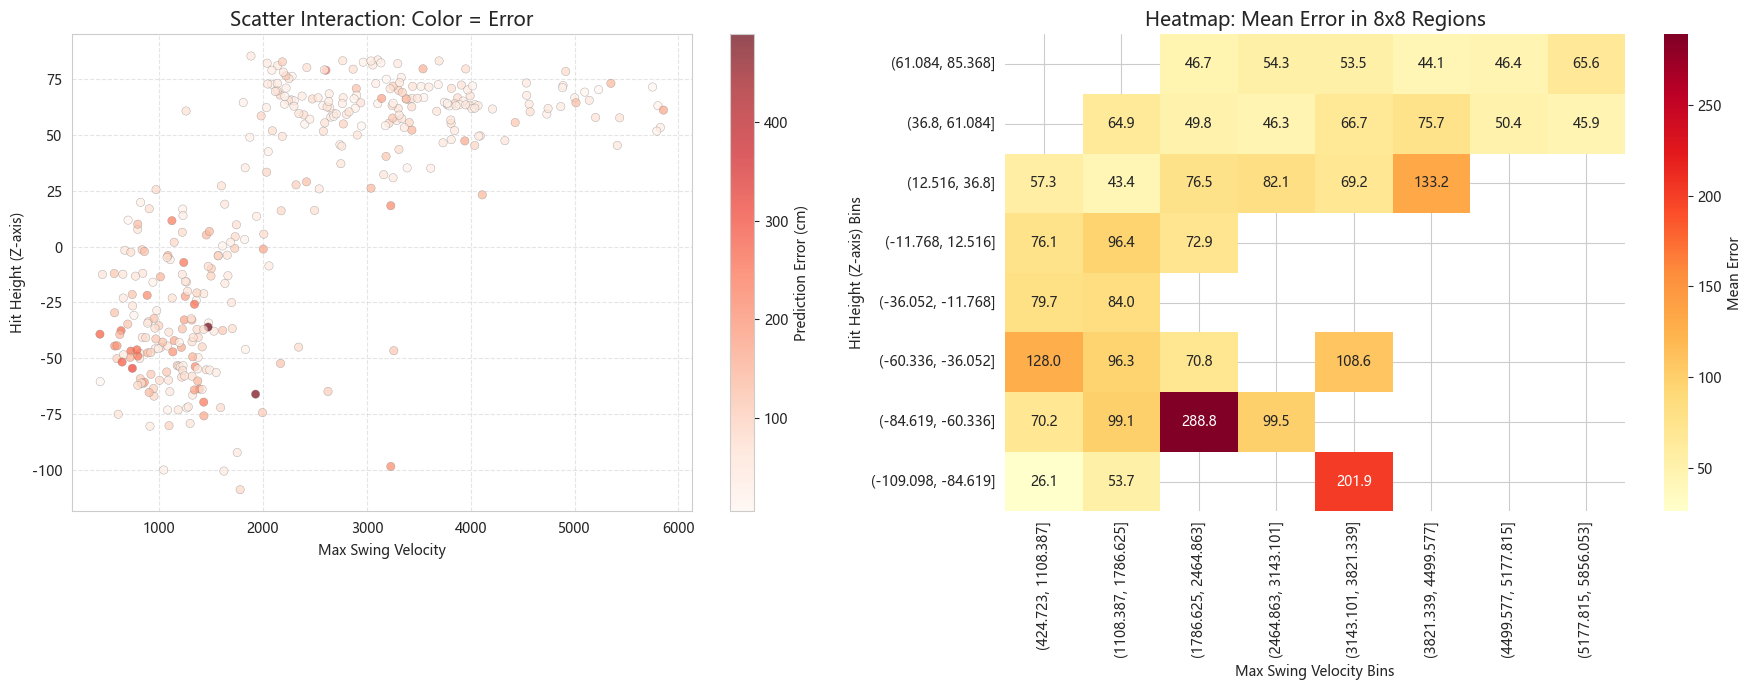

In [62]:
# 分析两个特征的共同作用

if 'df' in locals():
    # 直接传入两个函数名即可
    analyze_feature_interaction(
        df, 
        DATA_FOLDER, 
        func_x=get_max_velocity,              # 特征 X：速度
        func_y=get_relative_height,           # 特征 Y：高度 (Z轴)
        x_name="Max Swing Velocity",
        y_name="Hit Height (Z-axis)"
    )